# Atividade 1: Computação Quântica

Alunos:
- Lucas Maciel Ferreira
- Vinicius Ferreira Matias

## Exercício 1
Imports:

In [2]:
from numpy import sqrt
import numpy as np
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram
import math
import cmath

Funções utilizadas:

True

<IPython.core.display.Latex object>

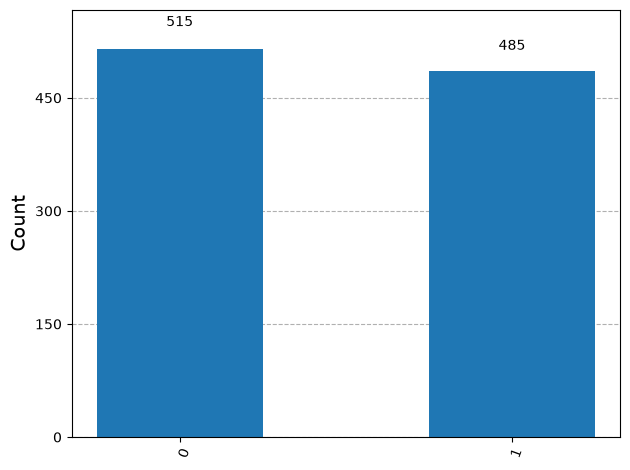

In [3]:
# Cria um estado de 1 qubit
sv=Statevector([1 / sqrt(2), 1j / sqrt(2)])

# Mostra se o estado eh valido
display(sv.is_valid())

# Mostra a representacao do estado em notacao de Dirac
display(sv.draw("latex"))

# Realiza a medicao do estado e plota o histograma dos resultados
stats = sv.sample_counts(1000)
plot_histogram(stats)

## Exercício 2

Criação do estado 

$\frac{2 + i}{3}\ket{0} - \frac{2}{3}\ket{1}$

In [4]:
sv2=Statevector([(2+1j)/3, -2/3])
display(sv2.is_valid())

True

Mostrando o estado em LaTeX

In [5]:
display(sv2.draw("latex"))

<IPython.core.display.Latex object>

Plotagem do histograma dos resultados da medicao do estado $\frac{2 + i}{3}\ket{0} - \frac{2}{3}\ket{1}$

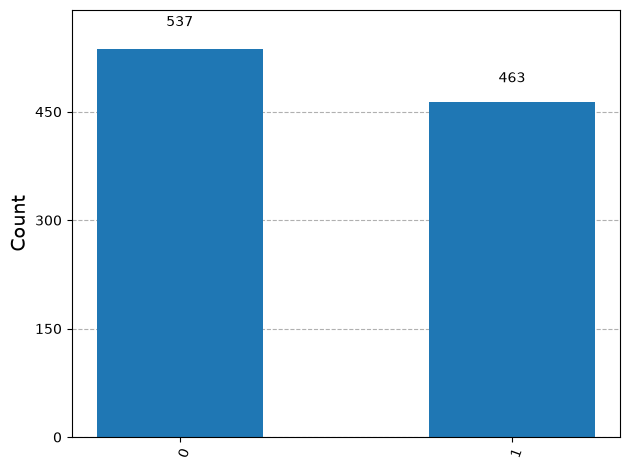

In [6]:
stats2 = sv2.sample_counts(1000)
plot_histogram(stats2)

## Exercício 3

#### Para obter um estado correspondente ao qubit do exercício anterior com a amplitude de $\ket{0}$ real, escreveremos o estado na seguinte forma:

$\ket{\psi}=e^{i\gamma}(cos(\frac{\theta}{2})\ket{0}+e^{i\tau}sen(\frac{\theta}{2})\ket{1})=e^{i\gamma}cos(\frac{\theta}{2})\ket{0}+e^{i\tau-\gamma}sen(\frac{\theta}{2})\ket{1}$

#### Para encontrar $\gamma$, temos:

$z=\frac{2+i}{3}$

$\gamma=arctan(\frac{Im(z)}{Re(z)})=arctan(\frac{1}{2})\approx0.464$

#### Para encontrar $\theta$, temos:

$|z|=\sqrt{(\frac{2}{3})^2+(\frac{1}{3})^2}=\frac{\sqrt{5}}{3}$

$\theta=2\times arccos(|z|)=2\times arccos(\frac{\sqrt{5}}{3})\approx2\times0.730=1.460$

#### Para encontrar $\tau$, temos:

$e^{i(\tau-\gamma)}=-1 \implies e^{i(\tau-0.464)}=e^{i\pi} \implies \tau \approx 3.141-0.464=2.677$

#### Enfim:

Para chegar na forma $(a+bi)\ket{0} + (c+di)\ket{1}$, temos:
- $a=cos(\frac{\theta}{2})$
- $b=0$
- $c=sen(\frac{\theta}{2})\times cos(\tau)$
- $d=sen(\frac{\theta}{2})\times sen(\tau)$

Logo, $\ket{\psi}=cos(\frac{\theta}{2})\ket{0}+(sen(\frac{\theta}{2})\times cos(\tau) + isen(\frac{\theta}{2})\times sen(\tau))\ket{1}$

$\ket{\psi}=cos(0.730)\ket{0}+(sen(0.730)\times cos(2.677) + isen(0.730)\times sen(2.677)\ket{1}$

$\ket{\psi}=\frac{\sqrt{5}}{3}\ket{0}+(\frac{2}{3}\times cos(2.677) + \frac{2i}{3}\times sen(2.677)\ket{1}$

In [7]:
sv3=Statevector([sqrt(5)/3, 2/3*(math.cos(2.677) + 1j*math.sin(2.677))])
display(sv3.is_valid())

True

In [8]:
display(sv3.draw("latex"))

<IPython.core.display.Latex object>

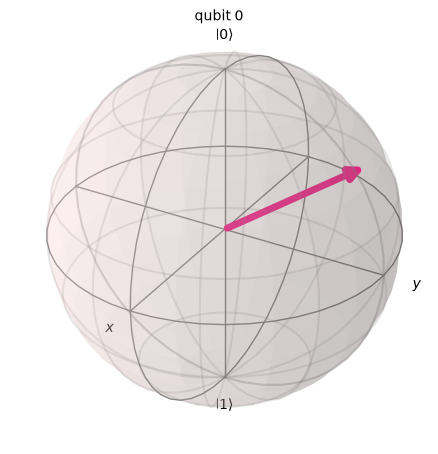

In [9]:
sv3.draw(output='bloch')

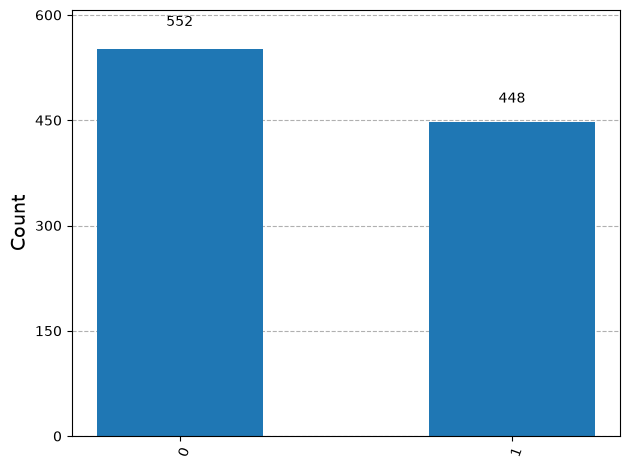

In [10]:
stats3 = sv3.sample_counts(1000)
plot_histogram(stats3)

## Exercício 3.5

Abaixo, o código responsável por realizar a conversão de um estado na forma

 $(a+bi)\ket{0} + (c+di)\ket{1}$
 
  em um estado equivalente, na forma 
  
  $e^{i\gamma}(cos(\frac{\theta}{2})\ket{0}+e^{i\tau}sen(\frac{\theta}{2})\ket{1})$


  Os resultados mostrados abaixo referem-se à entrada $\frac{2 + i}{3}\ket{0} - \frac{2}{3}\ket{1}$ (Estado do exercício 2).

In [14]:
from numpy import sqrt
import numpy as np
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram
from fractions import Fraction
import math
from math import sqrt, atan2
from cmath import exp

safe_dictionary = {
    "sqrt": math.sqrt,
    "sin": math.sin,
    "cos": math.cos,
}
a = float(Fraction(eval(input("Digite o a: "), {"__builtins__": None}, safe_dictionary)))
print(a)
b = float(Fraction(eval(input("Digite o b: "), {"__builtins__": None}, safe_dictionary)))
print(b)
c = float(Fraction(eval(input("Digite o c: "), {"__builtins__": None}, safe_dictionary)))
print(c)
d = float(Fraction(eval(input("Digite o d: "), {"__builtins__": None}, safe_dictionary)))
print(d)

amplitude_0_ket = sqrt(a**2 + b**2)
amplitude_1_ket = sqrt(c**2 + d**2)
phase_0_ket = atan2(b,a)
phase_1_ket = atan2(d,c)

sv=Statevector([amplitude_0_ket,(amplitude_1_ket)*exp(1j*(phase_1_ket-phase_0_ket))])

display(sv.is_valid())

0.6666666666666666
0.3333333333333333
-0.6666666666666666
0.0


True

In [15]:
display(sv.draw("latex"))

<IPython.core.display.Latex object>

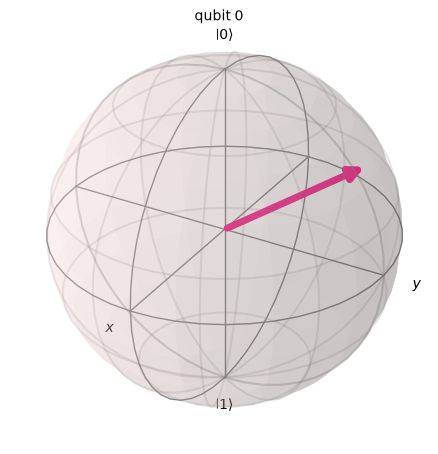

In [16]:
sv.draw(output='bloch')

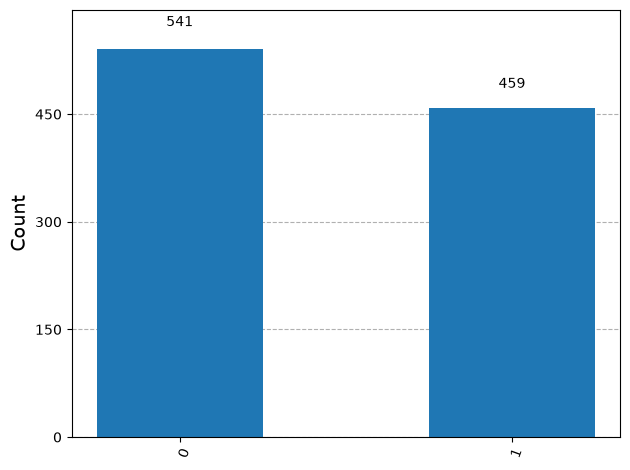

In [17]:
stats = sv.sample_counts(1000)
plot_histogram(stats)